### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [137]:
data = pd.read_csv('data/coupons.csv')

In [138]:
data.head()



,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [139]:
# Get column names as a list
columns_list = data.columns.tolist()

# Print the list
print(columns_list)

# # Example: rename specific columns
# data = data.rename(columns={
#     'old_column1': 'new_column1',
#     'old_column2': 'new_column2'
# })



['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon', 'expiration', 'gender', 'age', 'maritalStatus', 'has_children', 'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Y']


2. Investigate the dataset for missing or problematic data.

In [140]:
# Check for any other problematic data, e.g., unexpected values in categorical columns

# Save the list of columns in df "data" in data_columns list
data_columns = data.columns.tolist()
# Get total number of rows
total_rows = len(data)

# for each column in data_columns, calculate the number of null values and percentage
null_summary = pd.DataFrame({
    'Column': data_columns,
    'Null_Count': [data[col].isnull().sum() for col in data_columns],
    'Null_Percentage': [(data[col].isnull().sum() / total_rows) * 100 for col in data_columns]
}) 
# Filter to only columns with null values
columns_with_nulls = null_summary[null_summary['Null_Count'] > 0]                                 

# Calculate the number of rows with any null values
rows_with_any_null = data.isnull().any(axis=1).sum()
rows_with_any_null_percentage = (rows_with_any_null / total_rows) * 100

print(f"Total number of rows: {total_rows}")
print(f"Number of rows with any null values: {rows_with_any_null} ({rows_with_any_null_percentage:.2f}%)")                             

# Investigate missing data
print("\nNull counts per column:")  
print(columns_with_nulls)


# Stop script here with exit()
# import sys   
# print("\nExiting script.")
# sys.exit()

# List all column names, one per line, include if there are numeric or categorical
print("\nColumn names in the dataset:")
for col in data_columns:
    col_type = "Numeric" if pd.api.types.is_numeric_dtype(data[col]) else "Not Numeric"
    print(f" - {col} ({col_type})")


      

Total number of rows: 12684
Number of rows with any null values: 12576 (99.15%)

Null counts per column:
                  Column  Null_Count  Null_Percentage
14                   car       12576        99.148534
15                   Bar         107         0.843582
16           CoffeeHouse         217         1.710817
17             CarryAway         151         1.190476
18  RestaurantLessThan20         130         1.024913
19      Restaurant20To50         189         1.490066

Column names in the dataset:
 - destination (Not Numeric)
 - passanger (Not Numeric)
 - weather (Not Numeric)
 - temperature (Numeric)
 - time (Not Numeric)
 - coupon (Not Numeric)
 - expiration (Not Numeric)
 - gender (Not Numeric)
 - age (Not Numeric)
 - maritalStatus (Not Numeric)
 - has_children (Numeric)
 - education (Not Numeric)
 - occupation (Not Numeric)
 - income (Not Numeric)
 - car (Not Numeric)
 - Bar (Not Numeric)
 - CoffeeHouse (Not Numeric)
 - CarryAway (Not Numeric)
 - RestaurantLessThan20 (Not

In [141]:
# Get non-numeric columns
non_numeric_cols = data.select_dtypes(include=['object']).columns

# For each non-numeric column with nulls, print list of values
for col in non_numeric_cols:
    if not pd.api.types.is_numeric_dtype(data[col]):
        print(f"\nUnique values in column '{col}':")
        value_counts = data[col].value_counts(dropna=False, normalize=True) * 100
        for value, pct in value_counts.items():
            print(f"{value}: {pct:.2f}%")



Unique values in column 'destination':
No Urgent Place: 49.53%
Home: 25.52%
Work: 24.94%

Unique values in column 'passanger':
Alone: 57.59%
Friend(s): 26.00%
Partner: 8.48%
Kid(s): 7.93%

Unique values in column 'weather':
Sunny: 79.38%
Snowy: 11.08%
Rainy: 9.54%

Unique values in column 'time':
6PM: 25.47%
7AM: 24.94%
10AM: 17.94%
2PM: 15.84%
10PM: 15.82%

Unique values in column 'coupon':
Coffee House: 31.50%
Restaurant(<20): 21.96%
Carry out & Take away: 18.87%
Bar: 15.90%
Restaurant(20-50): 11.76%

Unique values in column 'expiration':
1d: 55.91%
2h: 44.09%

Unique values in column 'gender':
Female: 51.32%
Male: 48.67%
Female : 0.01%

Unique values in column 'age':
21: 20.92%
26: 20.18%
31: 16.08%
50plus: 14.10%
36: 10.40%
41: 8.62%
46: 5.41%
below21: 4.31%

Unique values in column 'maritalStatus':
Married partner: 40.21%
Single: 37.46%
Unmarried partner: 17.23%
Divorced: 4.07%
Widowed: 1.02%

Unique values in column 'education':
Some college - no degree: 34.30%
Bachelors degree:

3. Decide what to do about your missing data -- drop, replace, other...

In [142]:
# remove all colunmns that have more than 5% null values
threshold = 0.05 * total_rows
cols_to_drop = columns_with_nulls[columns_with_nulls['Null_Count'] > threshold]['Column'].tolist()
data_cleaned = data.drop(columns=cols_to_drop)          
print(f"\nColumns dropped due to exceeding {threshold} null values: {cols_to_drop}")
print(f"Remaining columns after cleaning: {data_cleaned.columns.tolist()}")


# Rename column Y in coupon_accepted
data_cleaned = data_cleaned.rename(columns={'Y': 'accepted_coupon'})


data_cleaned['age'] = data_cleaned['age'].replace('50plus', '50')
data_cleaned['age'] = data_cleaned['age'].replace('below21', '20')
data_cleaned['age'] = pd.to_numeric(data_cleaned['age'])
# Cleaning 'Gender' column
data_cleaned['gender'] = data_cleaned['gender'].replace('Female ', 'Female')




Columns dropped due to exceeding 634.2 null values: ['car']
Remaining columns after cleaning: ['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon', 'expiration', 'gender', 'age', 'maritalStatus', 'has_children', 'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Y']


In [143]:
# Get non-numeric columns
non_numeric_cols = data_cleaned.select_dtypes(include=['object']).columns

# For each non-numeric column with nulls, print list of values
for col in non_numeric_cols:
    if not pd.api.types.is_numeric_dtype(data_cleaned[col]):
        print(f"\nUnique values in column '{col}':")
        value_counts = data_cleaned[col].value_counts(dropna=False, normalize=True) * 100
        for value, pct in value_counts.items():
            print(f"{value}: {pct:.2f}%")



Unique values in column 'destination':
No Urgent Place: 49.53%
Home: 25.52%
Work: 24.94%

Unique values in column 'passanger':
Alone: 57.59%
Friend(s): 26.00%
Partner: 8.48%
Kid(s): 7.93%

Unique values in column 'weather':
Sunny: 79.38%
Snowy: 11.08%
Rainy: 9.54%

Unique values in column 'time':
6PM: 25.47%
7AM: 24.94%
10AM: 17.94%
2PM: 15.84%
10PM: 15.82%

Unique values in column 'coupon':
Coffee House: 31.50%
Restaurant(<20): 21.96%
Carry out & Take away: 18.87%
Bar: 15.90%
Restaurant(20-50): 11.76%

Unique values in column 'expiration':
1d: 55.91%
2h: 44.09%

Unique values in column 'gender':
Female: 51.33%
Male: 48.67%

Unique values in column 'maritalStatus':
Married partner: 40.21%
Single: 37.46%
Unmarried partner: 17.23%
Divorced: 4.07%
Widowed: 1.02%

Unique values in column 'education':
Some college - no degree: 34.30%
Bachelors degree: 34.18%
Graduate degree (Masters or Doctorate): 14.60%
Associates degree: 9.09%
High School Graduate: 7.13%
Some High School: 0.69%

Unique v

4. What proportion of the total observations chose to accept the coupon?



In [144]:
# Rename column 'accepted' to 'accepted_coupon'
# Show how many accepted coupons in total and as a percenta
total_accepted = data_cleaned['accepted_coupon'].sum()
percentage_accepted = (total_accepted / len(data_cleaned)) * 100
print(f"\nTotal accepted coupons: {total_accepted} ({percentage_accepted:.2f}%)")


Total accepted coupons: 7210 (56.84%)


5. Use a bar plot to visualize the `coupon` column.

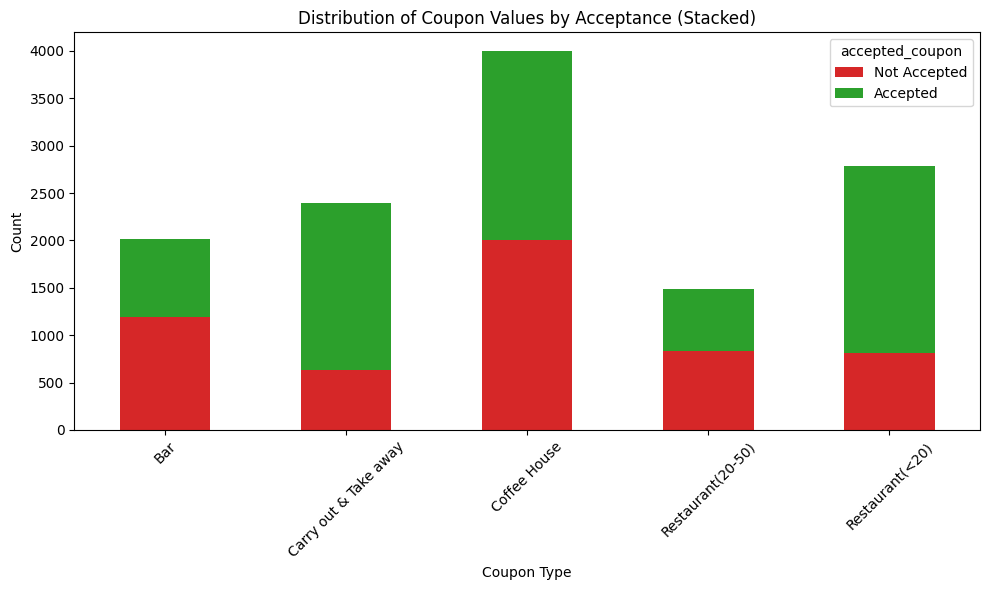

In [145]:
# Use a bar plot to visualize the `coupon` column. show break down by accepted_coupon for each coupon type
# Stacked bar chart of coupon types broken down by acceptance
ct = pd.crosstab(data_cleaned['coupon'], data_cleaned['accepted_coupon'])
ct = ct.rename(columns={0: 'Not Accepted', 1: 'Accepted'})

ax = ct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#d62728', '#2ca02c'])
ax.set_title('Distribution of Coupon Values by Acceptance (Stacked)')
ax.set_xlabel('Coupon Type')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='accepted_coupon')
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

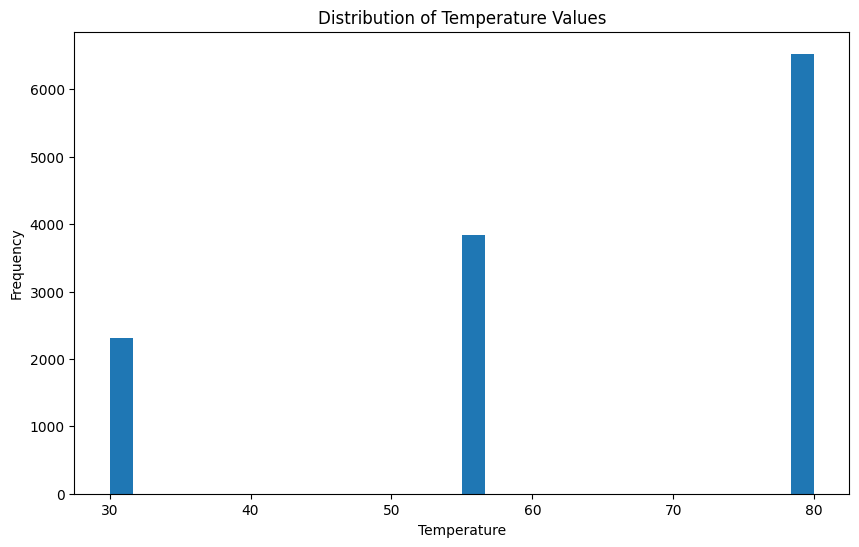

In [146]:
# Use a histogram to visualize the temperature column.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
data['temperature'].plot(kind='hist', bins=30)
plt.title('Distribution of Temperature Values')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [147]:
# Create a new `DataFrame` that contains just the bar coupons. 
bar_coupons = data_cleaned[data_cleaned['coupon'] == 'Bar']

2. What proportion of bar coupons were accepted?


In [148]:
data_select = bar_coupons

# What percentage of bar coupons were accepted? (use column accepted_coupon, values 1 for accepted, 0 for not accepted)
data_select['accepted_coupon'].sum() * 100 / len(data_select)         
print(f"Percentage of accepted bar coupons: {percentage_accepted:.2f}%")

Percentage of accepted bar coupons: 56.84%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


Acceptance rate for bar visits 3 or fewer times a month: 37.06%
Acceptance rate for bar visits more than 3 times a month: 76.88%


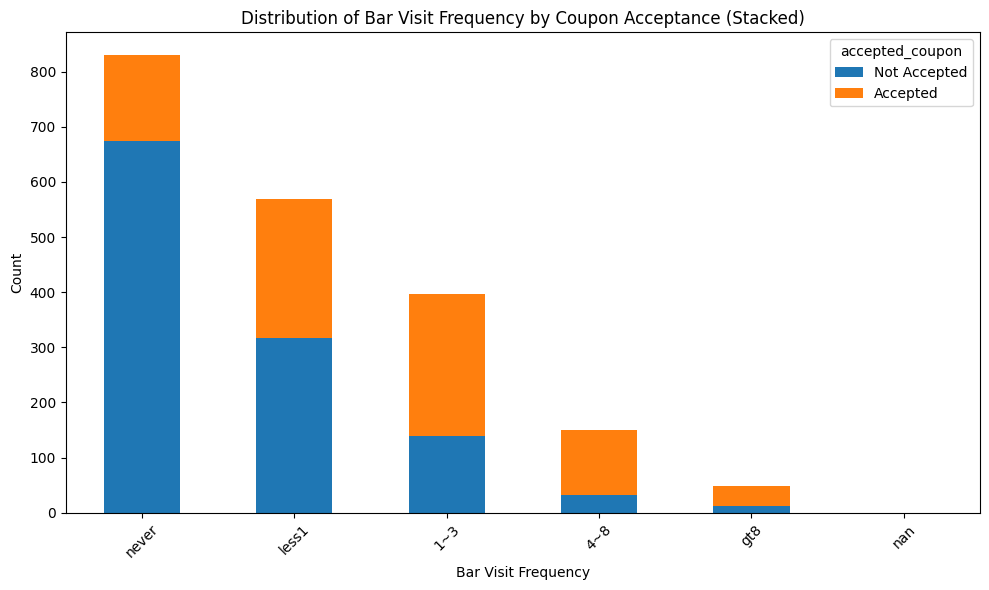

In [149]:
#  Compare the acceptance rate between those who went to a Bar 3 or fewer times a month to those who went more.

data_select = bar_coupons

low_freq = data_select[data_select['Bar'].isin(['never','less1','1~3'])]
high_freq = data_select[data_select['Bar'].isin(['4~8', 'gt8'])]    
low_freq_acceptance = (low_freq['accepted_coupon'].sum() / len(low_freq)) * 100
high_freq_acceptance = (high_freq['accepted_coupon'].sum() / len(high_freq)) *100
print(f"Acceptance rate for bar visits 3 or fewer times a month: {low_freq_acceptance:.2f}%")
print(f"Acceptance rate for bar visits more than 3 times a month: {high_freq_acceptance:.2f}%")                 


# Use a bar plot to visualize the 'Bar' column ub bar_coupons. show break down by accepted_coupon for each coupon type
ct_bar = pd.crosstab(data_select['Bar'], data_select['accepted_coupon'])
ct_bar = ct_bar.rename(columns={0: 'Not Accepted', 1: 'Accepted'})  

order = ['never', 'less1', '1~3', '4~8', 'gt8', 'nan']
ct_bar = ct_bar.reindex(order, fill_value=0)

ax = ct_bar.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])
ax.set_title('Distribution of Bar Visit Frequency by Coupon Acceptance (Stacked)')
ax.set_xlabel('Bar Visit Frequency')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='accepted_coupon')
plt.tight_layout()
plt.show()

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [150]:
# 4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


# Unique values in column 'Bar':
# never: 40.97%
# less1: 27.45%
# 1~3: 19.50%
# 4~8: 8.48%
# gt8: 2.75%
# nan: 0.84%

data_select = bar_coupons

group1 = data_select[(data_select['Bar'].isin(['1~3','4~8','gt8'])) & (data_select['age'] > 25)]
group2 = data_select[~data_select['Bar'].isin(['never','less1']) & (data_select['age'] <= 25)]



group1 = (group1['accepted_coupon'].sum() / len(group1)) * 100
group2 = (group2['accepted_coupon'].sum() / len(group2)) * 100
print(f"\nAcceptance rate for Group1 (go to a bar more than once a month and are over the age of 25): {group1:.2f}%")
print(f"Acceptance rate for bar visits more than 3 times a month: {group2:.2f}%")  


Acceptance rate for Group1 (go to a bar more than once a month and are over the age of 25): 69.52%
Acceptance rate for bar visits more than 3 times a month: 66.67%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [151]:
# 5. Compare the acceptance rate between 
# - drivers who go to bars more than once a month and had passengers that were not a kid 
# - and had occupations other than farming, fishing, or forestry.


data_select = bar_coupons
g1_mask = (
    data_select['Bar'].isin(['1~3','4~8','gt8'])
    & ~data_select['passanger'].isin(['Kid(s)'])
    & ~data_select['occupation'].isin(['Farming, Fishing, or Forestry'])
)

group1 = data_select[g1_mask]
group2 = data_select[~g1_mask]



group1 = (group1['accepted_coupon'].sum() / len(group1)) * 100
group2 = (group2['accepted_coupon'].sum() / len(group2)) * 100
print("Group1 : \n- go to bars more than once a month, and \n- had passengers that were not a kid and \n- had occupations other than farming, fishing, or forestry.)")
print(f"Acceptance rate for Group1: {group1:.2f}%")
print(f"Acceptance rate for Group2 (not Group1): {group2:.2f}%")  

Group1 : 
- go to bars more than once a month, and 
- had passengers that were not a kid and 
- had occupations other than farming, fishing, or forestry.)
Acceptance rate for Group1: 71.32%
Acceptance rate for Group2 (not Group1): 29.60%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [152]:
# 6. Compare the acceptance rates between those drivers who:
# - go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
# - go to bars more than once a month and are under the age of 30 *OR*
# - go to cheap restaurants more than 4 times a month and income is less than 50K.


g1_mask = (
    data_select['Bar'].isin(['1~3','4~8','gt8'])
    & ~data_select['passanger'].isin(['Kid(s)'])
    & ~data_select['maritalStatus'].isin(['Widowed'])
)

g2_mask = (
    data_select['Bar'].isin(['1~3','4~8','gt8'])
    & (data_select['age'] < 30)
)

g3_mask = (
    data_select['RestaurantLessThan20'].isin(['4~8','gt8'])
    & (data_select['income'].isin(['Less than $12500','$12500 - $24999','$25000 - $37499','$37500 - $49999']))
)

group1 = data_select[g1_mask]
group2 = data_select[g2_mask]
group3 = data_select[g3_mask]

group1 = (group1['accepted_coupon'].sum() / len(group1)) * 100
group2 = (group2['accepted_coupon'].sum() / len(group2)) * 100
group3 = (group3['accepted_coupon'].sum() / len(group3)) * 100
print(f"Acceptance rate for Group1: {group1:.2f}%")
print(f"Acceptance rate for Group2: {group2:.2f}%")
print(f"Acceptance rate for Group3: {group3:.2f}%")

Acceptance rate for Group1: 71.32%
Acceptance rate for Group2: 72.17%
Acceptance rate for Group3: 45.35%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [153]:
# Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

# hypothesis = (
# Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

# hypothesis = (
hypothesis = (
    f"Frequent bar-goers are much more likely to accept bar coupons (>1/month: {high_freq_acceptance:.1f}% "
    f"vs <=3/month: {low_freq_acceptance:.1f}%).\n"
    f"Subgroups who go >1/month and are over 25 or under 30 also show high acceptance "
    f"({group1:.1f}%, {group2:.1f}%).\n"
    f"By contrast, frequent cheap-restaurant-goers with lower income accept less ({group3:.1f}%).\n"
    "Hypothesis: social, frequent bar patrons (younger adults and mid-age, not widowed, typically without kids) \n"
    "are the most likely to accept bar coupons."
)
print(hypothesis)
# )
# print(hypothesis)
# )
# print(hypothesis)

Frequent bar-goers are much more likely to accept bar coupons (>1/month: 76.9% vs <=3/month: 37.1%).
Subgroups who go >1/month and are over 25 or under 30 also show high acceptance (71.3%, 72.2%).
By contrast, frequent cheap-restaurant-goers with lower income accept less (45.3%).
Hypothesis: social, frequent bar patrons (younger adults and mid-age, not widowed, typically without kids) 
are the most likely to accept bar coupons.


### Independent Investigation

Using the Coffee House coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [154]:
# 1. Create a new `DataFrame` that contains just the Coffee House coupons. 
coffee_coupons = data_cleaned[data_cleaned['coupon'] == 'Coffee House']

data_select = coffee_coupons

# 2. What percentage of Coffee House  coupons were accepted? (use column accepted_coupon, values 1 for accepted, 0 for not accepted)
data_select['accepted_coupon'].sum() * 100 / len(data_select)         
print(f"Percentage of accepted Coffee House coupons: {percentage_accepted:.2f}%")

Percentage of accepted Coffee House coupons: 56.84%


Acceptance rate for Coffee House  visits 3 or fewer times a month: 44.94%
Acceptance rate for Coffee House  visits more than 3 times a month: 67.50%


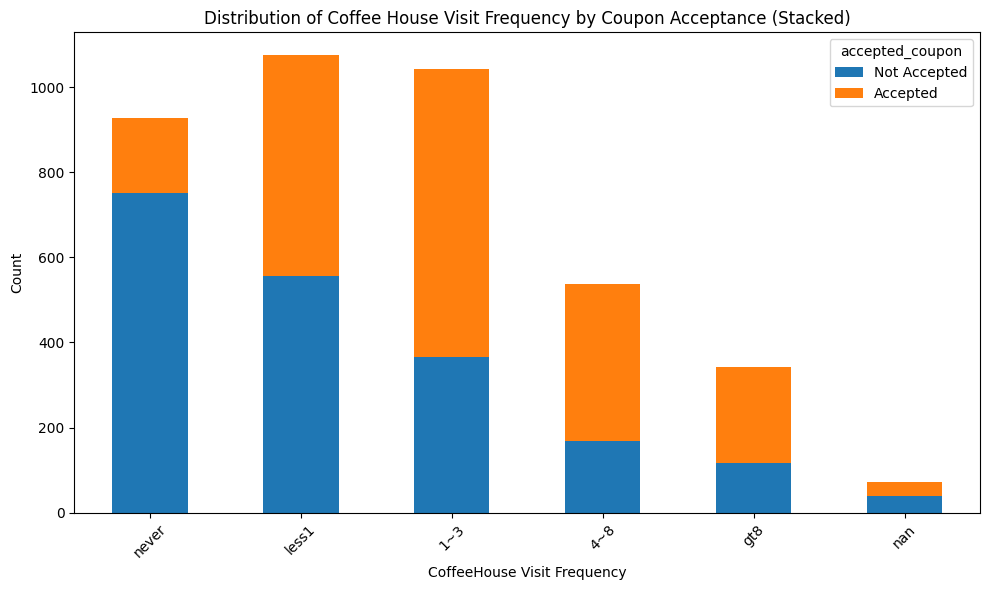


Acceptance rates by Coffee House visit frequency:
never: 18.88%
less1: 48.19%
1~3: 64.78%
4~8: 68.59%
gt8: 65.79%
nan: 45.83%


In [155]:
#  3. Compare the acceptance rate between those who went to a Coffee House 3 or fewer times a month to those who went more.

low_freq = data_select[data_select['CoffeeHouse'].isin(['never','less1','1~3'])]
high_freq = data_select[data_select['CoffeeHouse'].isin(['4~8', 'gt8'])]    
low_freq_acceptance = (low_freq['accepted_coupon'].sum() / len(low_freq)) * 100
high_freq_acceptance = (high_freq['accepted_coupon'].sum() / len(high_freq)) *100
print(f"Acceptance rate for Coffee House  visits 3 or fewer times a month: {low_freq_acceptance:.2f}%")
print(f"Acceptance rate for Coffee House  visits more than 3 times a month: {high_freq_acceptance:.2f}%")                 


# Use a Coffee House  plot to visualize the 'CoffeeHouse' column ub coffee_coupons. show break down by accepted_coupon for each coupon type
ct_chouse = pd.crosstab(data_select['CoffeeHouse'].fillna('nan'), data_select['accepted_coupon'])
ct_chouse = ct_chouse.rename(columns={0: 'Not Accepted', 1: 'Accepted'})

order = ['never', 'less1', '1~3', '4~8', 'gt8', 'nan']
ct_chouse = ct_chouse.reindex(order, fill_value=0)

ax = ct_chouse.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])
ax.set_title('Distribution of Coffee House Visit Frequency by Coupon Acceptance (Stacked)')
ax.set_xlabel('CoffeeHouse Visit Frequency')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='accepted_coupon')
plt.tight_layout()
plt.show()

# Give acceptance rate for each Coffee House visits rate.
value_counts = data_select['CoffeeHouse'].value_counts(dropna=False) * 100
print("\nAcceptance rates by Coffee House visit frequency:")
for value in order:
    count = data_select[data_select['CoffeeHouse'].fillna('nan') == value]['accepted_coupon'].sum()
    total = data_select[data_select['CoffeeHouse'].fillna('nan') == value].shape[0]
    acceptance_rate = (count / total) * 100 if total > 0 else 0
    print(f"{value}: {acceptance_rate:.2f}%")  
    

In [156]:
# Give acceptance rate for each Coffee House visits rate over 1 per month. Break it down by age. 
age_groups = {
    'below21': (0, 20),
    '21-25': (21, 25),
    '26-30': (26, 30),
    '31-40': (31, 40),
    '41-50': (41, 50),
    '50plus': (51, 100)
} 
for age_group, (age_min, age_max) in age_groups.items():
    print(f"\nAcceptance rates for Coffee House visits over 1 per month for age group {age_group} ({age_min}-{age_max}):")
    for visit_freq in ['1~3','4~8', 'gt8']:
        subset = data_select[
            (data_select['CoffeeHouse'] == visit_freq) &
            (data_select['age'] >= age_min) &
            (data_select['age'] <= age_max)
        ]
        if len(subset) > 0:
            acceptance_rate = (subset['accepted_coupon'].sum() / len(subset)) * 100
            print(f"  {visit_freq}: {acceptance_rate:.2f}%")
        else:
            print(f"  {visit_freq}: No data available")



Acceptance rates for Coffee House visits over 1 per month for age group below21 (0-20):
  1~3: 69.86%
  4~8: 91.67%
  gt8: 80.95%

Acceptance rates for Coffee House visits over 1 per month for age group 21-25 (21-25):
  1~3: 67.54%
  4~8: 70.44%
  gt8: 77.97%

Acceptance rates for Coffee House visits over 1 per month for age group 26-30 (26-30):
  1~3: 70.08%
  4~8: 68.00%
  gt8: 54.21%

Acceptance rates for Coffee House visits over 1 per month for age group 31-40 (31-40):
  1~3: 58.87%
  4~8: 68.29%
  gt8: 61.63%

Acceptance rates for Coffee House visits over 1 per month for age group 41-50 (41-50):
  1~3: 60.70%
  4~8: 64.29%
  gt8: 73.91%

Acceptance rates for Coffee House visits over 1 per month for age group 50plus (51-100):
  1~3: No data available
  4~8: No data available
  gt8: No data available


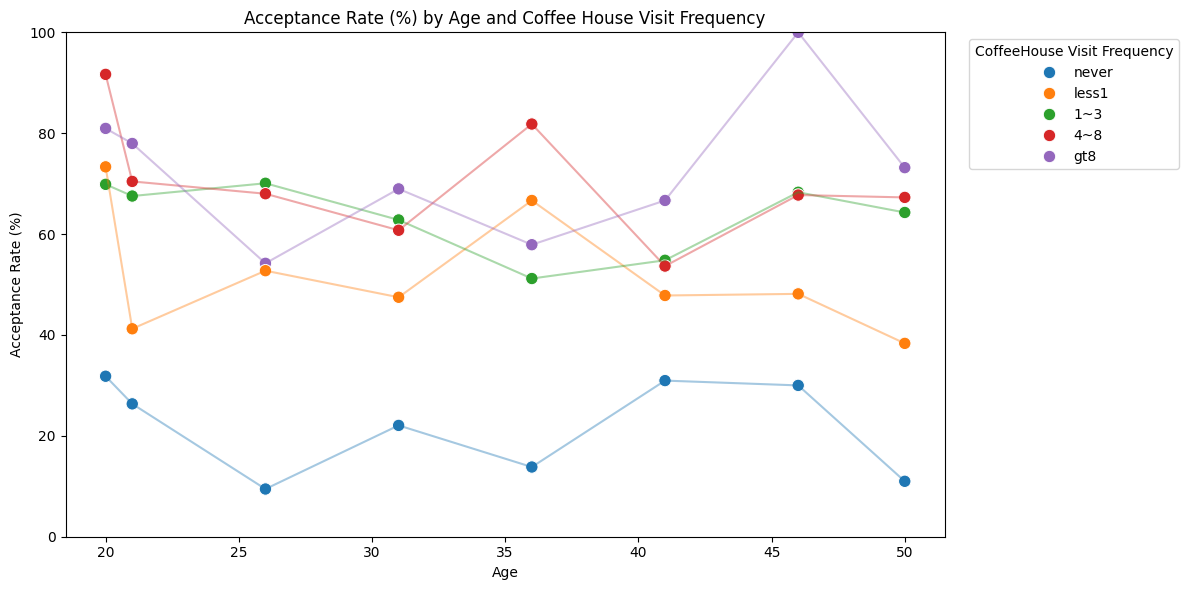

In [157]:
# Use Seaborn to create a scatter showing acceptance rate by Coffee House visit frequency and age

# Aggregate acceptance rate per (age, CoffeeHouse)
grp = (
    data_select
    .dropna(subset=['CoffeeHouse'])               # remove missing visit-frequency labels
    .groupby(['age', 'CoffeeHouse'], as_index=False)['accepted_coupon']
    .mean()
)
grp['acceptance_pct'] = grp['accepted_coupon'] * 100

# Ensure CoffeeHouse ordering if available
order_no_nan = [o for o in order if o != 'nan'] if 'order' in globals() else ['never','less1','1~3','4~8','gt8']
grp['CoffeeHouse'] = pd.Categorical(grp['CoffeeHouse'], categories=order_no_nan, ordered=True)

plt.figure(figsize=(12, 6))
# Scatter points
sns.scatterplot(
    data=grp,
    x='age',
    y='acceptance_pct',
    hue='CoffeeHouse',
    palette='tab10',
    s=80,
    edgecolor='w'
)
# Add faint lines to show trend per visit-frequency
sns.lineplot(
    data=grp.sort_values('age'),
    x='age',
    y='acceptance_pct',
    hue='CoffeeHouse',
    palette='tab10',
    legend=False,
    alpha=0.4
)

plt.title('Acceptance Rate (%) by Age and Coffee House Visit Frequency')
plt.xlabel('Age')
plt.ylabel('Acceptance Rate (%)')
plt.ylim(0, 100)
plt.legend(title='CoffeeHouse Visit Frequency', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# 4. Compare the acceptance rate between drivers who go to a Coffee House more than once a month and are over the age of 25 to the all others.  Is there a difference?


# Unique values in column 'CoffeeHouse':
# never: 40.97%
# less1: 27.45%
# 1~3: 19.50%
# 4~8: 8.48%
# gt8: 2.75%
# nan: 0.84%

group1 = data_select[(data_select['CoffeeHouse'].isin(['4~8','gt8'])) & (data_select['age'] <= 25)]
group2 = data_select[~data_select['CoffeeHouse'].isin(['never','less1']) & (data_select['age'] > 25)]

n1 = len(group1)
n2 = len(group2)

rate1 = (group1['accepted_coupon'].sum() / n1) * 100 if n1 > 0 else np.nan
rate2 = (group2['accepted_coupon'].sum() / n2) * 100 if n2 > 0 else np.nan

print(f"Group1 (CoffeeHouse 4+ times/month & age ≤ 25): {n1} samples — acceptance rate = {rate1:.2f}%")
print(f"Group2 (CoffeeHouse > never/less1 & age > 25): {n2} samples — acceptance rate = {rate2:.2f}%")


Acceptance rate for Group1 (go to a Coffee House more than 4 times a month and are 25 or younger): 74.90%
Acceptance rate for Coffee House visits more than 3 times a month: 62.90%


In [158]:
# Give acceptance rate for each Coffee House. Break it down by occupation. 
occupations = data_select['occupation'].unique()
for occupation in occupations:
    print(f"\nAcceptance rates for Coffee House visits over 1 per month for occupation: {occupation}")
    for visit_freq in ['1~3','4~8', 'gt8']:
        subset = data_select[
            (data_select['CoffeeHouse'] == visit_freq) &
            (data_select['occupation'] == occupation)
        ]
        if len(subset) > 0:
            acceptance_rate = (subset['accepted_coupon'].sum() / len(subset)) * 100
            print(f"  {visit_freq}: {acceptance_rate:.2f}%")
        else:
            print(f"  {visit_freq}: No data available")


Acceptance rates for Coffee House visits over 1 per month for occupation: Unemployed
  1~3: 75.74%
  4~8: 77.33%
  gt8: 55.81%

Acceptance rates for Coffee House visits over 1 per month for occupation: Architecture & Engineering
  1~3: 65.00%
  4~8: No data available
  gt8: No data available

Acceptance rates for Coffee House visits over 1 per month for occupation: Student
  1~3: 68.12%
  4~8: 72.28%
  gt8: 65.00%

Acceptance rates for Coffee House visits over 1 per month for occupation: Education&Training&Library
  1~3: 51.82%
  4~8: 69.23%
  gt8: 43.48%

Acceptance rates for Coffee House visits over 1 per month for occupation: Healthcare Support
  1~3: 73.53%
  4~8: No data available
  gt8: 20.00%

Acceptance rates for Coffee House visits over 1 per month for occupation: Healthcare Practitioners & Technical
  1~3: 90.00%
  4~8: 100.00%
  gt8: 85.71%

Acceptance rates for Coffee House visits over 1 per month for occupation: Sales & Related
  1~3: 54.84%
  4~8: 51.85%
  gt8: 81.25%

A

In [159]:
# Give acceptance rate for each Coffee House. Break it down by passenger for age under 21.
for passenger in data_select['passanger'].unique():
    print(f"\nAcceptance rates for Coffee House visits over 1 per month for passenger: {passenger} (age < 21)")
    for visit_freq in ['1~3','4~8', 'gt8']:
        subset = data_select[
            (data_select['CoffeeHouse'] == visit_freq) &
            (data_select['passanger'] == passenger) &
            (data_select['age'] < 21)
        ]
        if len(subset) > 0:
            acc = (subset['accepted_coupon'].sum() / len(subset)) * 100
            print(f"  {visit_freq}: {acc:.2f}% ({len(subset)} samples)")
        else:
            print(f"  {visit_freq}: No data available")


Acceptance rates for Coffee House visits over 1 per month for passenger: Friend(s) (age < 21)
  1~3: 88.46% (26 samples)
  4~8: 80.00% (5 samples)
  gt8: 100.00% (3 samples)

Acceptance rates for Coffee House visits over 1 per month for passenger: Kid(s) (age < 21)
  1~3: No data available
  4~8: No data available
  gt8: No data available

Acceptance rates for Coffee House visits over 1 per month for passenger: Alone (age < 21)
  1~3: 58.97% (39 samples)
  4~8: 94.44% (18 samples)
  gt8: 73.33% (15 samples)

Acceptance rates for Coffee House visits over 1 per month for passenger: Partner (age < 21)
  1~3: 62.50% (8 samples)
  4~8: 100.00% (1 samples)
  gt8: 100.00% (3 samples)


In [160]:
# 5. Compare the acceptance rate between 
# - drivers who go to Coffee House more than once a month and had passengers that were not a kid 
# - and had occupations other than farming, fishing, or forestry.

g1_mask = (
    data_select['CoffeeHouse'].isin(['4~8','gt8'])
    & data_select['age'] < 21
    # & data_select['passanger'].isin(['Partner'])
    & data_select['occupation'].isin(['Unemployed'])
)   

group1 = data_select[g1_mask]
group2 = data_select[~g1_mask]

group1 = (group1['accepted_coupon'].sum() / len(group1)) * 100
group2 = (group2['accepted_coupon'].sum() / len(group2)) * 100
print("Group1 : \n- go to Coffee House more than once a month, and \n- had passengers that were not a kid and \n- had occupations other than farming, fishing, or forestry.)")
print(f"Acceptance rate for Group1: {group1:.2f}%")
print(f"Acceptance rate for Group2 (not Group1): {group2:.2f}%")  

Group1 : 
- go to Coffee House more than once a month, and 
- had passengers that were not a kid and 
- had occupations other than farming, fishing, or forestry.)
Acceptance rate for Group1: 51.88%
Acceptance rate for Group2 (not Group1): 49.64%


In [161]:
# 6. Compare the acceptance rates between those drivers who:
# - go to Coffee House more than once a month, had passengers that were not a kid, and were not widowed *OR*
# - go to Coffee House more than once a month and are under the age of 30 *OR*
# - go to cheap restaurants more than 4 times a month and income is less than 50K.


g1_mask = (
    data_select['CoffeeHouse'].isin(['1~3','4~8','gt8'])
    & ~data_select['passanger'].isin(['Kid(s)'])
    & ~data_select['maritalStatus'].isin(['Widowed'])
)

g2_mask = (
    data_select['CoffeeHouse'].isin(['1~3','4~8','gt8'])
    & (data_select['age'] < 30)
)

g3_mask = (
    data_select['RestaurantLessThan20'].isin(['4~8','gt8'])
    & (data_select['income'].isin(['Less than $12500','$12500 - $24999','$25000 - $37499','$37500 - $49999']))
)

group1 = data_select[g1_mask]
group2 = data_select[g2_mask]
group3 = data_select[g3_mask]

group1 = (group1['accepted_coupon'].sum() / len(group1)) * 100
group2 = (group2['accepted_coupon'].sum() / len(group2)) * 100
group3 = (group3['accepted_coupon'].sum() / len(group3)) * 100
print(f"Acceptance rate for Group1: {group1:.2f}%")
print(f"Acceptance rate for Group2: {group2:.2f}%")
print(f"Acceptance rate for Group3: {group3:.2f}%")

Acceptance rate for Group1: 66.08%
Acceptance rate for Group2: 68.93%
Acceptance rate for Group3: 54.30%


In [162]:
# Based on these observations, what do you hypothesize about drivers who accepted the Coffee House coupons?

hypothesis_coffee = (
    f"Frequent coffee-house visitors (>1/month) accept Coffee House coupons at {high_freq_acceptance:.1f}% "
    f"vs {low_freq_acceptance:.1f}% for <=3/month. "
    "Subgroups that visit frequently (different age/occupation segments) show varying acceptance rates, "
    "but overall regular, social coffee-house patrons (often younger or mid-age adults, typically without kids) "
    "are more likely to accept Coffee House coupons."
)

print(hypothesis_coffee)




Frequent coffee-house visitors (>1/month) accept Coffee House coupons at 67.5% vs 44.9% for <=3/month. Subgroups that visit frequently (different age/occupation segments) show varying acceptance rates, but overall regular, social coffee-house patrons (often younger or mid-age adults, typically without kids) are more likely to accept Coffee House coupons.


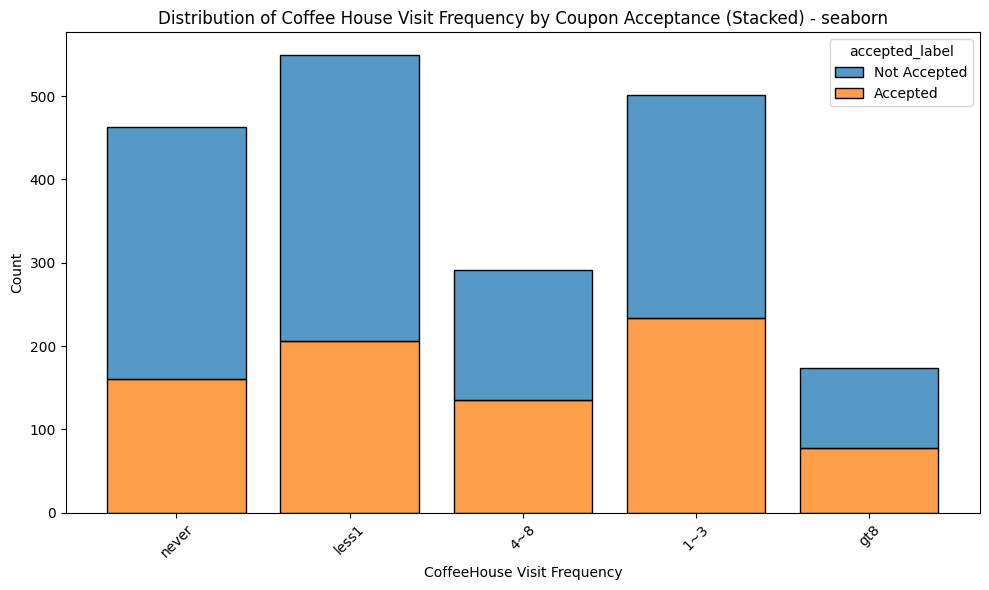

In [134]:
# Polot distribution of Coffee House Visit Frequency by Coupon Acceptance (Stacked) using seaborn
# prepare labels and plot stacked counts with seaborn
plot_df = data_select.copy()
plot_df['accepted_label'] = plot_df['accepted_coupon'].map({0: 'Not Accepted', 1: 'Accepted'})

plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df, x='CoffeeHouse', hue='accepted_label',
             multiple='stack', shrink=0.8, palette=['#1f77b4', '#ff7f0e'])
plt.title('Distribution of Coffee House Visit Frequency by Coupon Acceptance (Stacked) - seaborn')
plt.xlabel('CoffeeHouse Visit Frequency')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()